In [1]:
%load_ext autoreload
%autoreload 2

import os, h5py
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files, parameters, buzzard

from msi.flow_conductor.likelihood_flow import LikelihoodFlow
from msi.flow_conductor import architecture
from msi.utils import input_output


# v16

In [2]:
msfm_conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v16/default.yaml")
base_dir = "/pscratch/sd/a/athomsen/deep_lss/v16/default/cls"

In [3]:
probe = "lensing"
params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]

model_name = "v1"
n_steps = 500_000

In [4]:
# probe = "clustering"
# params = ["Om", "s8", "w0", "bg1", "bg2", "bg3", "bg4"]

# model_name = ""
# n_steps = 500_000

In [5]:
# probe = "combined"
# params = ["Om", "s8", "w0", "Aia", "n_Aia", "bta", "bg1", "bg2", "bg3", "bg4"]

# model_name = ""
# n_steps = 500_000

# constants

In [6]:
buzzard_cosmo = buzzard.get_cosmo(msfm_conf, params)
n_params = len(params)

pred_dir = os.path.join(base_dir, probe, model_name)
pred_file = os.path.join(pred_dir, f"preds_{n_steps}.h5")

grid_preds, grid_cosmos, all_obs_preds = input_output.load_network_preds_simple(pred_file)

26-03-10 08:24:11 input_output INF   Loading predictions from /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/v1/preds_500000.h5 
26-03-10 08:24:11 input_output INF   grid_preds.shape = (200000, 12) 
26-03-10 08:24:11 input_output INF   grid_cosmos.shape = (200000, 6) 
26-03-10 08:24:11 input_output INF   DESy3 with shape (12,) 
26-03-10 08:24:11 input_output INF   bench_box_mean with shape (12,) 
26-03-10 08:24:11 input_output INF   bench_box_stack with shape (80, 12) 
26-03-10 08:24:11 input_output INF   bench_fidu_mean with shape (12,) 
26-03-10 08:24:11 input_output INF   bench_fidu_stack with shape (80, 12) 
26-03-10 08:24:11 input_output INF   bench_particle_mean with shape (12,) 
26-03-10 08:24:11 input_output INF   bench_particle_stack with shape (80, 12) 
26-03-10 08:24:11 input_output INF   bench_redshift_mean with shape (12,) 
26-03-10 08:24:11 input_output INF   bench_redshift_stack with shape (80, 12) 
26-03-10 08:24:11 input_output INF   grid_0 with shape (12,) 


# normalizing flow $p(x | \theta)$

### initialization

In [7]:
model = LikelihoodFlow(
    params, 
    msfm_conf, 
    feature_dim=grid_preds.shape[-1],    
    out_dir=pred_dir, 
    load_existing=True,
)

26-03-10 08:25:09 likelihood_b INF   Set up the model directory /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/v1/likelihood_flow 
26-03-10 08:25:09 likelihood_f INF   Using the default context embedding network: 
26-03-10 08:25:09 likelihood_f INF   <class 'enflows.nn.nets.resnet.ResidualNet'> 
26-03-10 08:25:09 likelihood_f INF   Using the default base distribution: 
26-03-10 08:25:09 likelihood_f INF   <class 'enflows.distributions.normal.StandardNormal'> 
26-03-10 08:25:10 likelihood_f INF   Using the default transform: 
26-03-10 08:25:10 likelihood_f INF   <class 'enflows.transforms.base.CompositeTransform'> 
26-03-10 08:25:10 likelihood_f INF   Initialized the normalizing flow 
26-03-10 08:25:10 likelihood_f INF   Running on device cuda with default float torch.float32 
26-03-10 08:25:10 likelihood_f WAR   Could not load the model from /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/v1/likelihood_flow/likelihood_flow.pt 


### training

26-03-10 08:25:23 likelihood_f INF   batch size = 10000 -> 20 steps per epoch for 100 epochs 
26-03-10 08:25:24 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 100 
100%|████████████████████████████|   | 100/100 [04:22<00:00,  2.62s/it]       lr: 1.00E-05, train: -15.53, vali: -15.32: 
26-03-10 08:29:46 likelihood_f INF   Saved the model to /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/v1/likelihood_flow/likelihood_flow.pt 
26-03-10 08:29:46 likelihood_f INF   Running conditional C2ST with 20000 real vs 20000 flow samples ... 
26-03-10 08:30:02 likelihood_f INF   C2ST accuracy: 0.4778 (ideal: 0.5, worst: 1.0) 


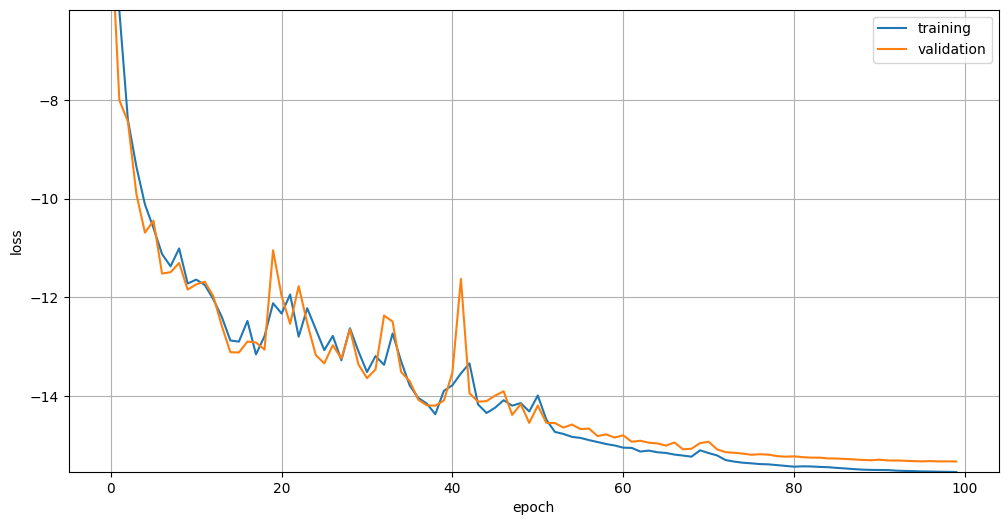

In [8]:
history = model.fit(
    x=grid_preds,
    theta=grid_cosmos,
    n_epochs=100,
    batch_size=10_000,
    scheduler_type="cosine",
    save_model=True,
    run_c2st=True,
)

# observation

## CosmoGrid

### grid

In [9]:
obs_dict = {}

n_examples = 4

for i_grid in range(n_examples):
    # unique cosmological parameters
    i_grid *= msfm_conf["analysis"]["grid"]["n_perms_per_cosmo"] * msfm_conf["analysis"]["n_patches"]
    
    obs_dict[f"grid_{i_grid}"] = {
        "pred": grid_preds[i_grid],
        "cosmo": {str(param): value for param, value in zip(params, grid_cosmos[i_grid])},
    }


### benchmarks

In [10]:
# obs_dict = {}
obs_cosmo = {str(param): value for param, value in zip(params, parameters.get_fiducials(params, msfm_conf))}

obs_labels = ["bench_fidu"]
obs_labels += ["bench_box", "bench_particle", "bench_redshift"]
# # obs_labels += ["source_clustering_bgs_low", "source_clustering_bgs_high"]
# # obs_labels = ["fidu_bary", "fidu_dmo"]
# # obs_labels += ["ia_shell"]

for obs_label in obs_labels:
    obs_label += "_mean"
    obs_preds = all_obs_preds[obs_label]
    
    obs_dict[obs_label] = {
        "pred": obs_preds, 
        "cosmo": obs_cosmo,
    }


## DES Y3

In [11]:
# obs_dict = {}

obs_label = "DESy3"

obs_dict[obs_label] = {
    "pred": all_obs_preds[obs_label],
    "cosmo": None,
}

## Buzzard

In [12]:
# obs_labels = []
# # obs_labels += [f"Buzzard_{i}" for i in [0] + list(range(2, 16))]
# obs_labels += ["Buzzard_mean"]
# # obs_labels += ["Buzzard_stack"]

# for obs_label in obs_labels:
#     obs_preds = all_obs_preds[obs_label]
    
#     obs_dict[obs_label] = {
#         "pred": obs_preds, 
#         "cosmo": obs_cosmo,
#     }

In [13]:
# obs_dict = {}

# # buzzard_indices = list(range(0, 16))
# # buzzard_indices.remove(1)
# buzzard_indices = [0, 2]
# buzzard_stack = []
# for i in buzzard_indices:
#     pred = all_obs_preds[f"Buzzard_{i}"]
#     buzzard_stack.append(pred)
    
#     # obs_dict[f"Buzzard_{i}"] = {
#     #     "pred": pred,
#     #     "cosmo": buzzard_cosmo,
#     # }

# buzzard_stack = np.stack(buzzard_stack, axis=0)

# obs_dict[f"Buzzard_mean"] = {
#     "pred": np.mean(buzzard_stack, axis=0),
#     "cosmo": buzzard_cosmo,
# }

# obs_dict[f"Buzzard_stack"] = {
#     "pred": np.stack(buzzard_stack, axis=0),
#     "cosmo": buzzard_cosmo,
# }

### MCMC and plotting


Starting with mock observation grid_0
26-03-10 08:30:32 likelihood_f INF   Sampling the posterior from a single observation 
26-03-10 08:30:32 likelihood_f WAR   wCDM 
26-03-10 08:30:32      mcmc.py INF   Initial values in prior: 46.9% 
26-03-10 08:30:32      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:26<00:00, 37.77it/s]

26-03-10 08:30:58      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:26<00:00, 37.65it/s]

26-03-10 08:31:25      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/v1/likelihood_flow/chain_grid_0.npy 


...

26-03-10 08:38:40  plotting.py INF   Saved the plot to /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/v1/likelihood_flow/contours_bench_redshift_mean.png 

Starting with mock observation DESy3
26-03-10 08:38:40 likelihood_f INF   Sampling the posterior from a single observation 
26-03-10 08:38:40 likelihood_f WAR   wCDM 
26-03-10 08:38:40      mcmc.py INF   Initial values in prior: 51.6% 
26-03-10 08:38:40      mcmc.py INF   Starting the burn in MCMC chain (1000 steps) 


100%|██████████| 1000/1000 [00:27<00:00, 36.90it/s]

26-03-10 08:39:07      mcmc.py INF   Starting the main MCMC chain (1000 steps) 



100%|██████████| 1000/1000 [00:28<00:00, 35.44it/s]

26-03-10 08:39:35      mcmc.py INF   Saved the MCMC chain to /pscratch/sd/a/athomsen/deep_lss/v16/default/cls/lensing/v1/likelihood_flow/chain_DESy3.npy 


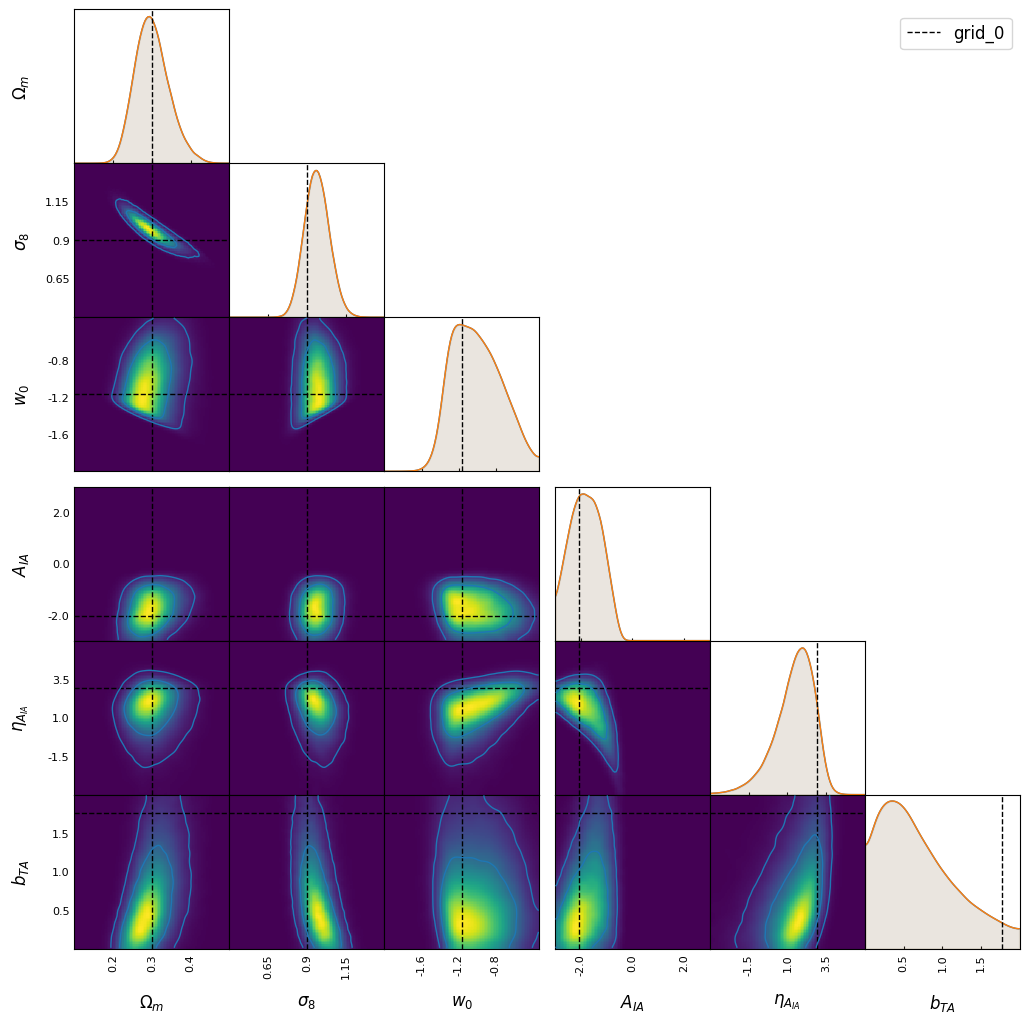

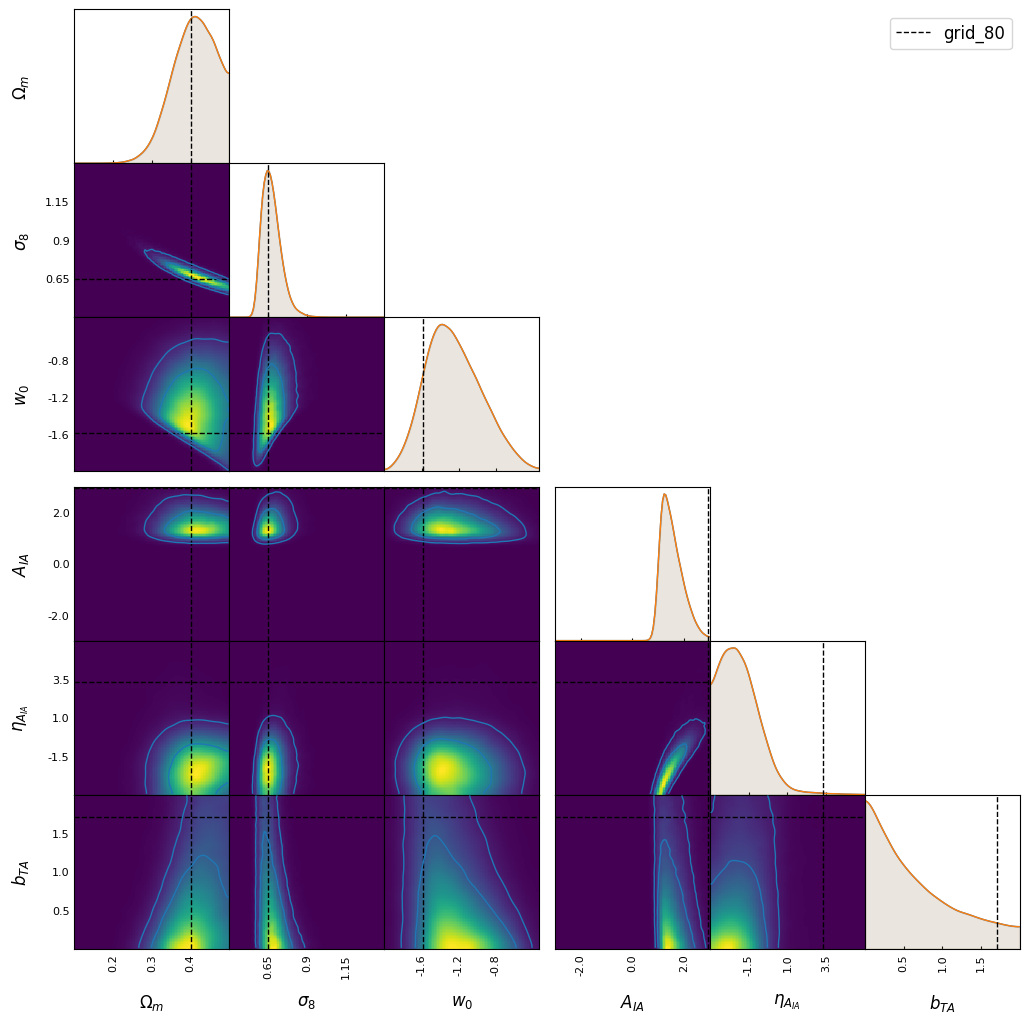

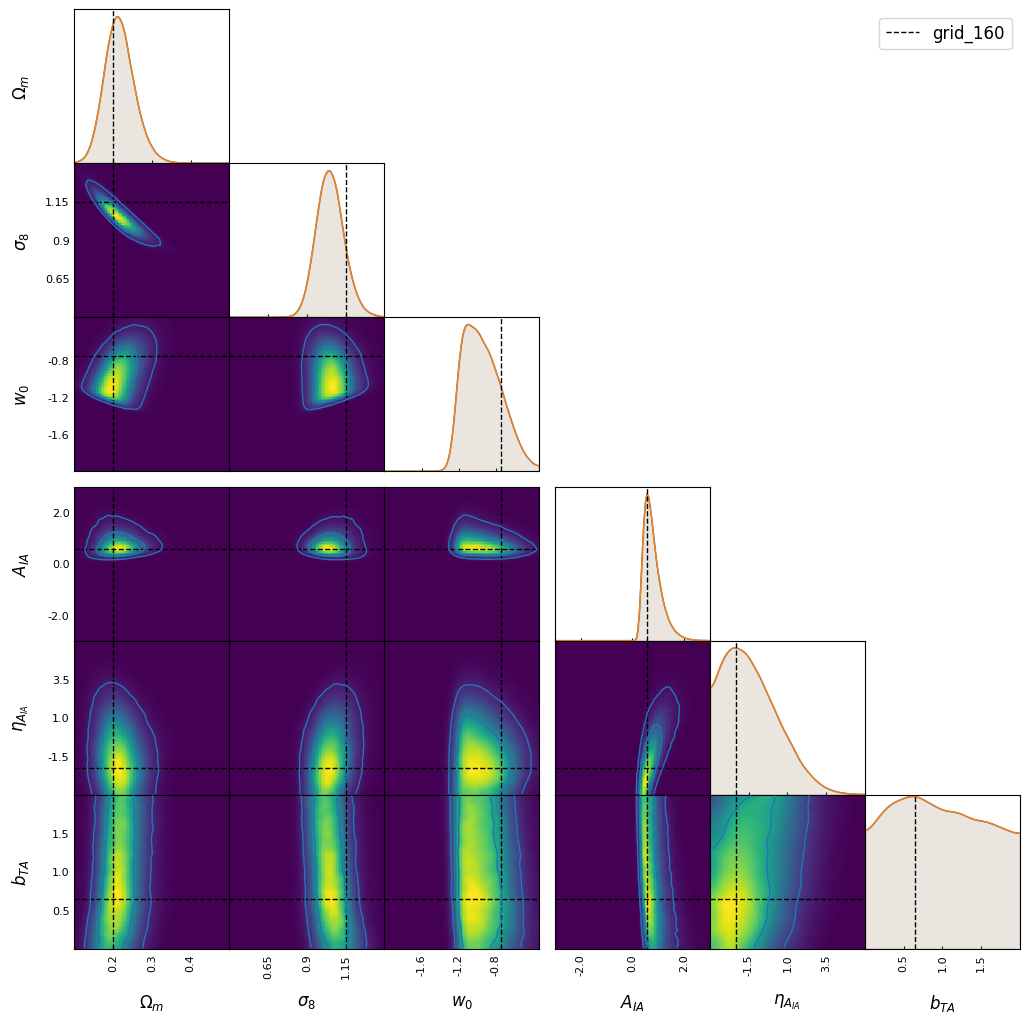

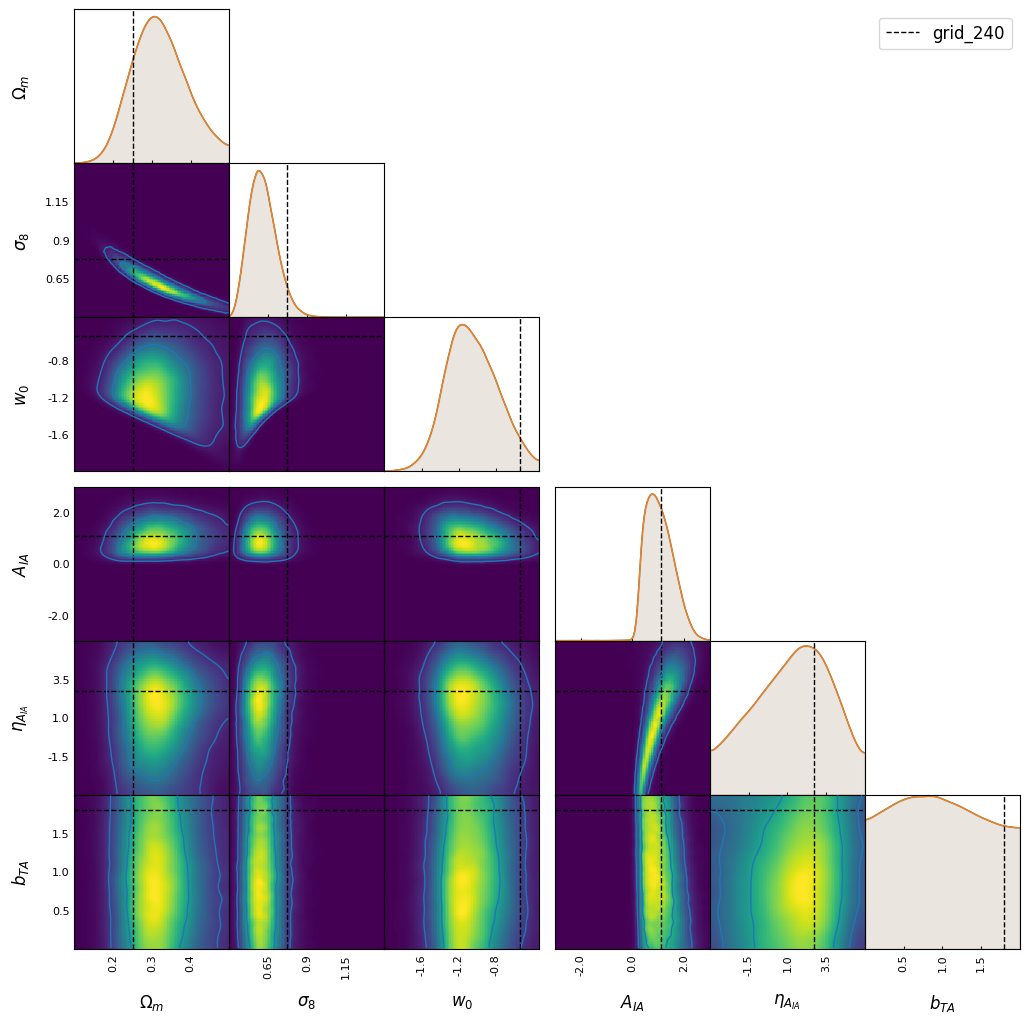

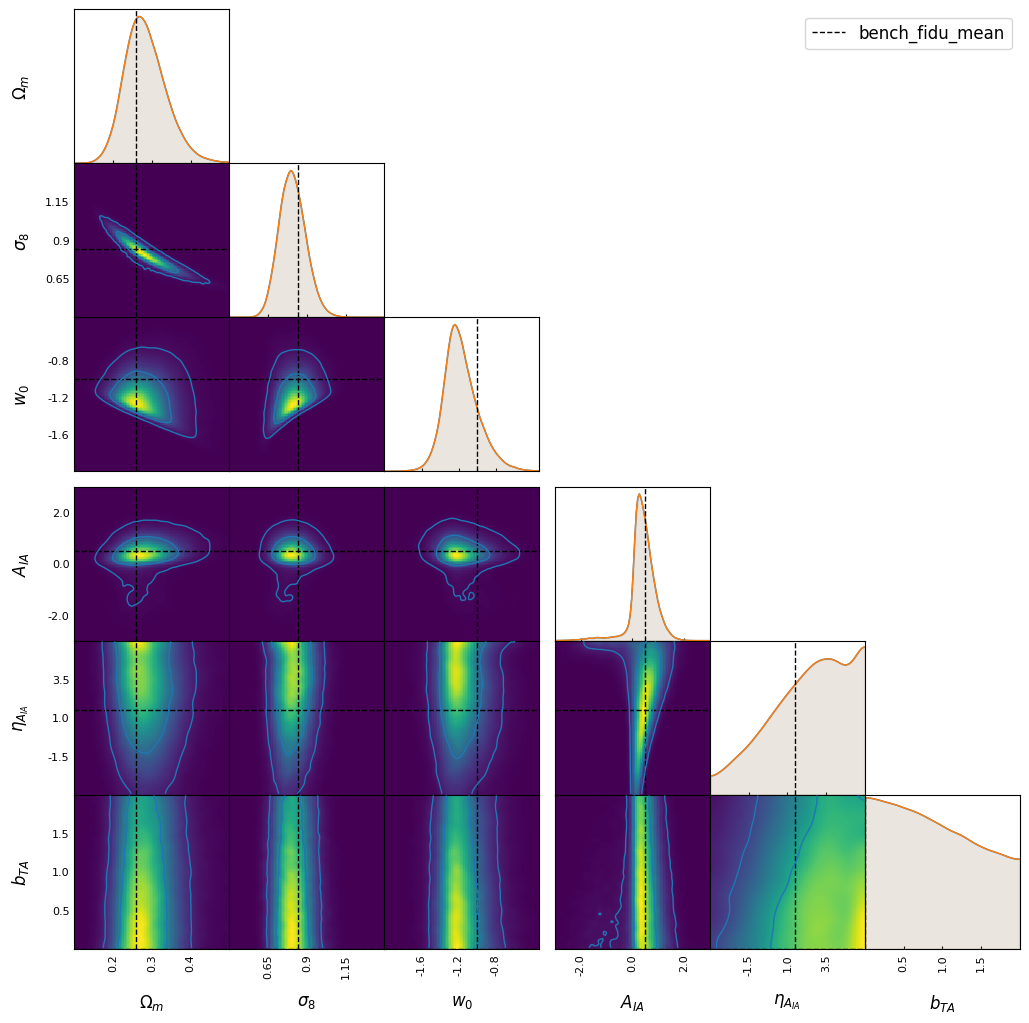

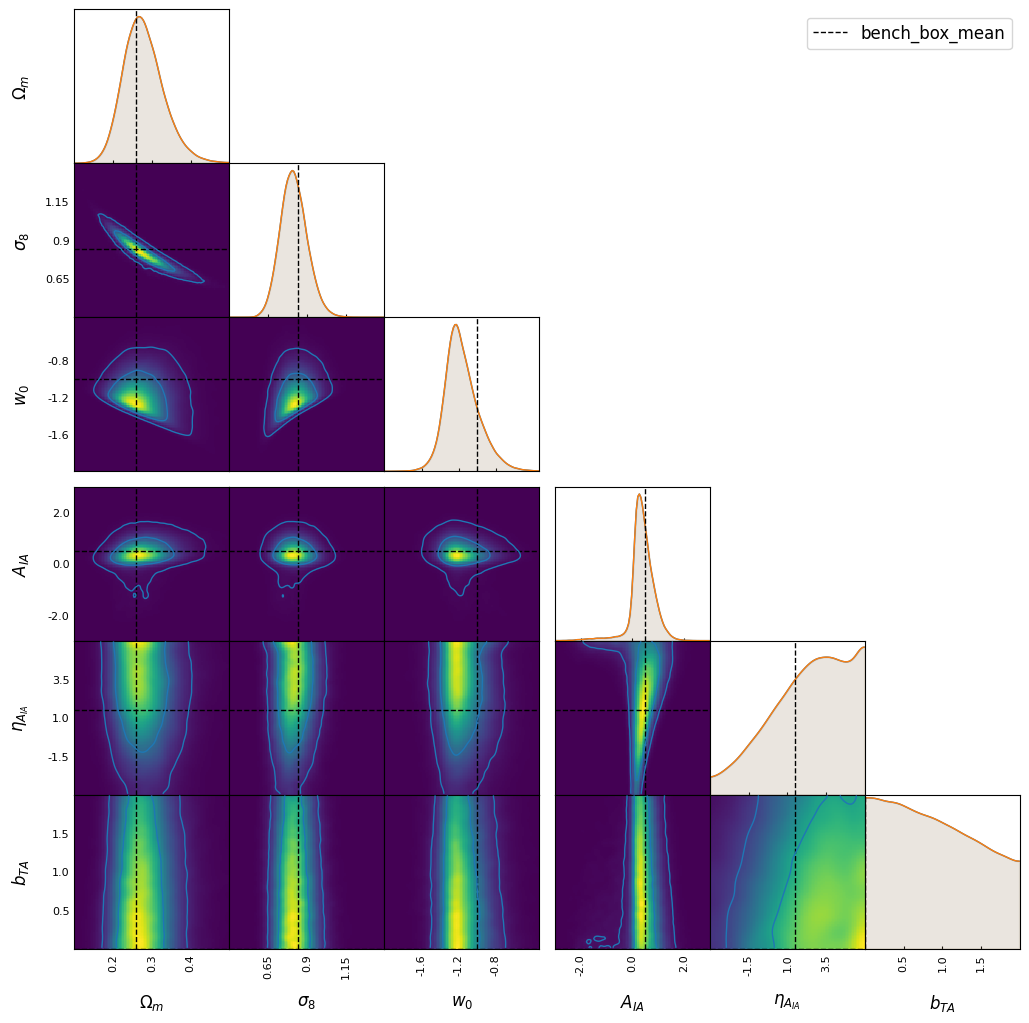

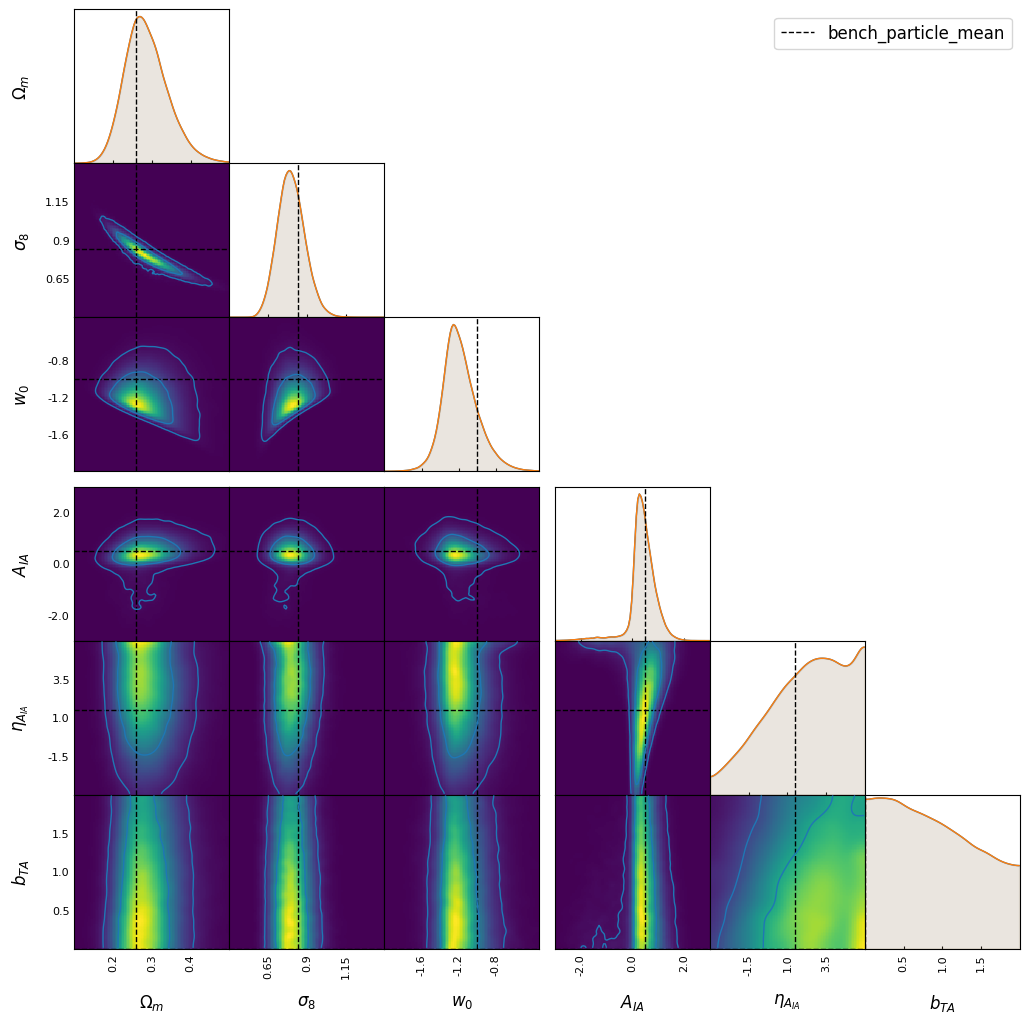

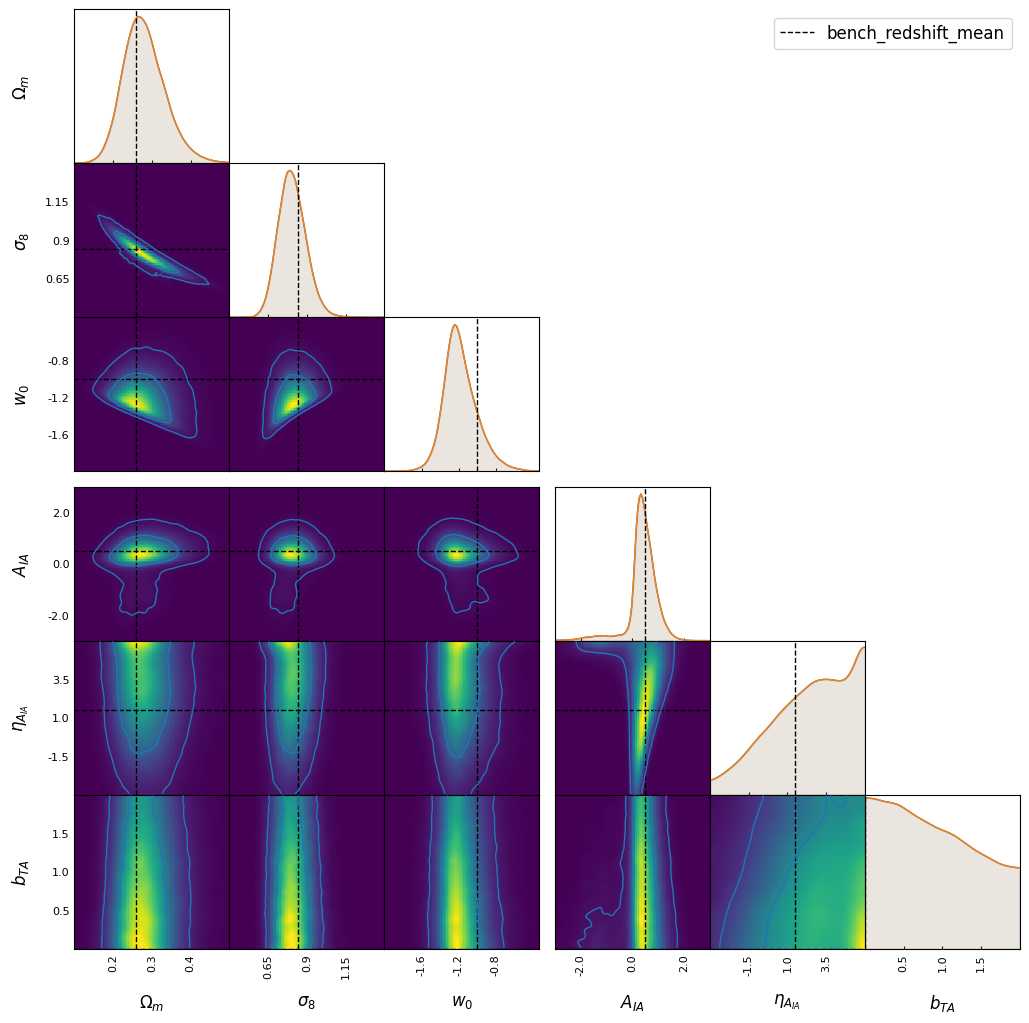

In [14]:
extra_label = ""

for key in obs_dict.keys():
    print(f"\nStarting with mock observation {key}")
    
    posterior_samples = model.sample_posterior(
        obs_dict[key]["pred"],
        label=key+extra_label,
        n_walkers=1024,
        n_steps=1000,
        n_burnin_steps=1000,
    )

    if not "des" in key.lower():
        model.plot_contours(
            posterior_samples,
            obs_point=obs_dict[key]["cosmo"],
            obs_label=key,
            label=key+extra_label,
            with_des_chain=False,
            density=True
        )